In [1]:
import pandas as pd
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
from tqdm import tqdm
import argparse
import glob
import xml.etree.ElementTree as ET
import cv2
import ast
import numpy as np


import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as immg

import random

import torch

import torchvision
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN

from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"


import warnings
warnings.filterwarnings("ignore")

# !pip install albumentations==0.4.6
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
zip_file_path = "/content/drive/MyDrive/Final project 2024-2025 /archive (1).zip"
unzip_destination = "/content/unzipped_files"

In [5]:
!unzip -o "{zip_file_path}" -d "{unzip_destination}"

Archive:  /content/drive/MyDrive/Final project 2024-2025 /archive (1).zip
  inflating: /content/unzipped_files/PCB_DATASET/Annotations/Missing_hole/01_missing_hole_01.xml  
  inflating: /content/unzipped_files/PCB_DATASET/Annotations/Missing_hole/01_missing_hole_02.xml  
  inflating: /content/unzipped_files/PCB_DATASET/Annotations/Missing_hole/01_missing_hole_03.xml  
  inflating: /content/unzipped_files/PCB_DATASET/Annotations/Missing_hole/01_missing_hole_04.xml  
  inflating: /content/unzipped_files/PCB_DATASET/Annotations/Missing_hole/01_missing_hole_05.xml  
  inflating: /content/unzipped_files/PCB_DATASET/Annotations/Missing_hole/01_missing_hole_06.xml  
  inflating: /content/unzipped_files/PCB_DATASET/Annotations/Missing_hole/01_missing_hole_07.xml  
  inflating: /content/unzipped_files/PCB_DATASET/Annotations/Missing_hole/01_missing_hole_08.xml  
  inflating: /content/unzipped_files/PCB_DATASET/Annotations/Missing_hole/01_missing_hole_09.xml  
  inflating: /content/unzipped_file

In [6]:
path_an = "/content/unzipped_files/PCB_DATASET/Annotations"
print(path_an)

/content/unzipped_files/PCB_DATASET/Annotations


In [7]:
dataset = {
            "xmin":[],
            "ymin":[],
            "xmax":[],
            "ymax":[],
            "class":[],
            "file":[],
            "width":[],
            "height":[],
           }
all_files = []
for path, subdirs, files in os.walk(path_an):
#     print([path, subdirs, files])
    for name in files:
        all_files.append(os.path.join(path, name))

# print(all_files)
print(type(dataset))
print(dataset)


<class 'dict'>
{'xmin': [], 'ymin': [], 'xmax': [], 'ymax': [], 'class': [], 'file': [], 'width': [], 'height': []}


In [8]:
for anno in all_files:
    # print(anno)
    tree = ET.parse(anno)

    for elem in tree.iter():
        # print(elem)

        if 'size' in elem.tag:
            # print('[size] in elem.tag ==> list(elem)\n'), print(list(elem))
            for attr in list(elem):
                if 'width' in attr.tag:
                    width = int(round(float(attr.text)))
                if 'height' in attr.tag:
                    height = int(round(float(attr.text)))

        if 'object' in elem.tag:
            # print('[object] in elem.tag ==> list(elem)\n'), print(list(elem))
            for attr in list(elem):

                # print('attr = %s\n' % attr)
                if 'name' in attr.tag:
                    name = attr.text
                    dataset['class']+=[name]
                    dataset['width']+=[width]
                    dataset['height']+=[height]
                    dataset['file']+=[anno.split('/')[-1][0:-4]]

                if 'bndbox' in attr.tag:
                    for dim in list(attr):
                        if 'xmin' in dim.tag:
                            xmin = int(round(float(dim.text)))
                            dataset['xmin']+=[xmin]
                        if 'ymin' in dim.tag:
                            ymin = int(round(float(dim.text)))
                            dataset['ymin']+=[ymin]
                        if 'xmax' in dim.tag:
                            xmax = int(round(float(dim.text)))
                            dataset['xmax']+=[xmax]
                        if 'ymax' in dim.tag:
                            ymax = int(round(float(dim.text)))
                            dataset['ymax']+=[ymax]

In [9]:
data=pd.DataFrame(dataset)
data

,xmin,ymin,xmax,ymax,class,file,width,height
0,703,1340,850,1379,spurious_copper,05_spurious_copper_08,2544,2156
1,1835,1309,1983,1349,spurious_copper,05_spurious_copper_08,2544,2156
2,1755,1363,1902,1399,spurious_copper,05_spurious_copper_08,2544,2156
3,152,1032,191,1171,spurious_copper,05_spurious_copper_08,2544,2156
4,2341,1640,2375,1751,spurious_copper,05_spurious_copper_08,2544,2156
...,...,...,...,...,...,...,...,...
2948,973,918,1087,985,short,08_short_08,2759,2154
2949,2248,1205,2335,1269,short,08_short_08,2759,2154
2950,2559,1231,2643,1334,short,08_short_08,2759,2154
2951,1076,1215,1148,1280,short,08_short_08,2759,2154


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
train, test = train_test_split(data, shuffle=True, test_size=0.2, random_state=34)

train.shape, test.shape

((2362, 8), (591, 8))

In [11]:
train.head()

,xmin,ymin,xmax,ymax,class,file,width,height
1838,858,1534,930,1618,open_circuit,10_open_circuit_06,2240,2016
2149,1626,890,1681,957,mouse_bite,04_mouse_bite_18,3056,2464
1784,678,1615,737,1663,open_circuit,12_open_circuit_06,2529,2530
1042,1905,1362,1964,1403,spur,05_spur_03,2544,2156
1992,1555,886,1627,951,mouse_bite,07_mouse_bite_07,2904,1921


In [12]:
test.head()

,xmin,ymin,xmax,ymax,class,file,width,height
90,2363,1310,2404,1411,spurious_copper,08_spurious_copper_02,2759,2154
1315,1170,1873,1221,1962,spur,04_spur_20,3056,2464
1244,1986,412,2067,463,spur,05_spur_10,2544,2156
1572,539,1453,602,1511,open_circuit,04_open_circuit_13,3056,2464
1515,1097,598,1151,655,open_circuit,07_open_circuit_06,2904,1921


In [13]:
classes_la = {"missing_hole": 0, "mouse_bite": 1, "open_circuit":2, "short": 3, 'spur': 4,'spurious_copper':5}

train["class"] = train["class"].apply(lambda x: classes_la[x])
test["class"] = test["class"].apply(lambda x: classes_la[x])

In [14]:
train.head()

,xmin,ymin,xmax,ymax,class,file,width,height
1838,858,1534,930,1618,2,10_open_circuit_06,2240,2016
2149,1626,890,1681,957,1,04_mouse_bite_18,3056,2464
1784,678,1615,737,1663,2,12_open_circuit_06,2529,2530
1042,1905,1362,1964,1403,4,05_spur_03,2544,2156
1992,1555,886,1627,951,1,07_mouse_bite_07,2904,1921


In [15]:
test.head()

,xmin,ymin,xmax,ymax,class,file,width,height
90,2363,1310,2404,1411,5,08_spurious_copper_02,2759,2154
1315,1170,1873,1221,1962,4,04_spur_20,3056,2464
1244,1986,412,2067,463,4,05_spur_10,2544,2156
1572,539,1453,602,1511,2,04_open_circuit_13,3056,2464
1515,1097,598,1151,655,2,07_open_circuit_06,2904,1921


In [16]:
# PJC (deep copy)
df = train.copy()

df_grp = df.groupby(['file'])
print(df_grp)

In [17]:
df_grp.size()

,0
file,
01_missing_hole_01,2
01_missing_hole_02,3
01_missing_hole_03,1
01_missing_hole_04,3
01_missing_hole_05,3
...,...
12_spurious_copper_06,4
12_spurious_copper_07,5
12_spurious_copper_08,5


In [18]:
image_name = '01_missing_hole_02'
image_group = df_grp.get_group(image_name)
print(image_group)

     xmin  ymin  xmax  ymax  class                file  width  height
852  2366   803  2406   860      0  01_missing_hole_02   3034    1586
851  2584   232  2650   298      0  01_missing_hole_02   3034    1586
853  1506   802  1559   856      0  01_missing_hole_02   3034    1586


In [19]:
bbox = image_group.loc[:,['xmin', 'ymin', 'xmax', 'ymax']]
print([bbox, type(bbox)])

[     xmin  ymin  xmax  ymax
852  2366   803  2406   860
851  2584   232  2650   298
853  1506   802  1559   856, <class 'pandas.core.frame.DataFrame'>]


In [20]:
def plot_image(image_name):
    print(image_name)
    image_group = df_grp.get_group(image_name)
    bbox = image_group.loc[:,['xmin', 'ymin', 'xmax', 'ymax']]
    path ="/content/unzipped_files/PCB_DATASET/images/"
    if "missing" in name.split('_'):
        path += 'Missing_hole/'
    if "mouse" in name.split('_'):
        path += 'Mouse_bite/'
    if "open" in name.split('_'):
        path += 'Open_circuit/'
    if "short" in name.split('_'):
        path += 'Short/'
    if "spur" in name.split('_'):
        path += 'Spur/'
    if "spurious" in name.split('_'):
        path += 'Spurious_copper/'

    img = immg.imread(path+""+name+'.jpg')
    fig,ax = plt.subplots(figsize=(18,10))
    ax.imshow(img,cmap='binary')
    for i in range(len(bbox)):
        box = bbox.iloc[i].values
        print(box)
        x,y,w,h = box[0], box[1], box[2]-box[0], box[3]-box[1]
        rect = matplotlib.patches.Rectangle((x,y),w,h,linewidth=1,edgecolor='r',facecolor='none',)
        # ax.text(*box[:2], image_group["class"].values, verticalalignment='top', color='white', fontsize=13, weight='bold')
        ax.add_patch(rect)
    plt.show()

01_missing_hole_02
[2366  803 2406  860]
[2584  232 2650  298]
[1506  802 1559  856]


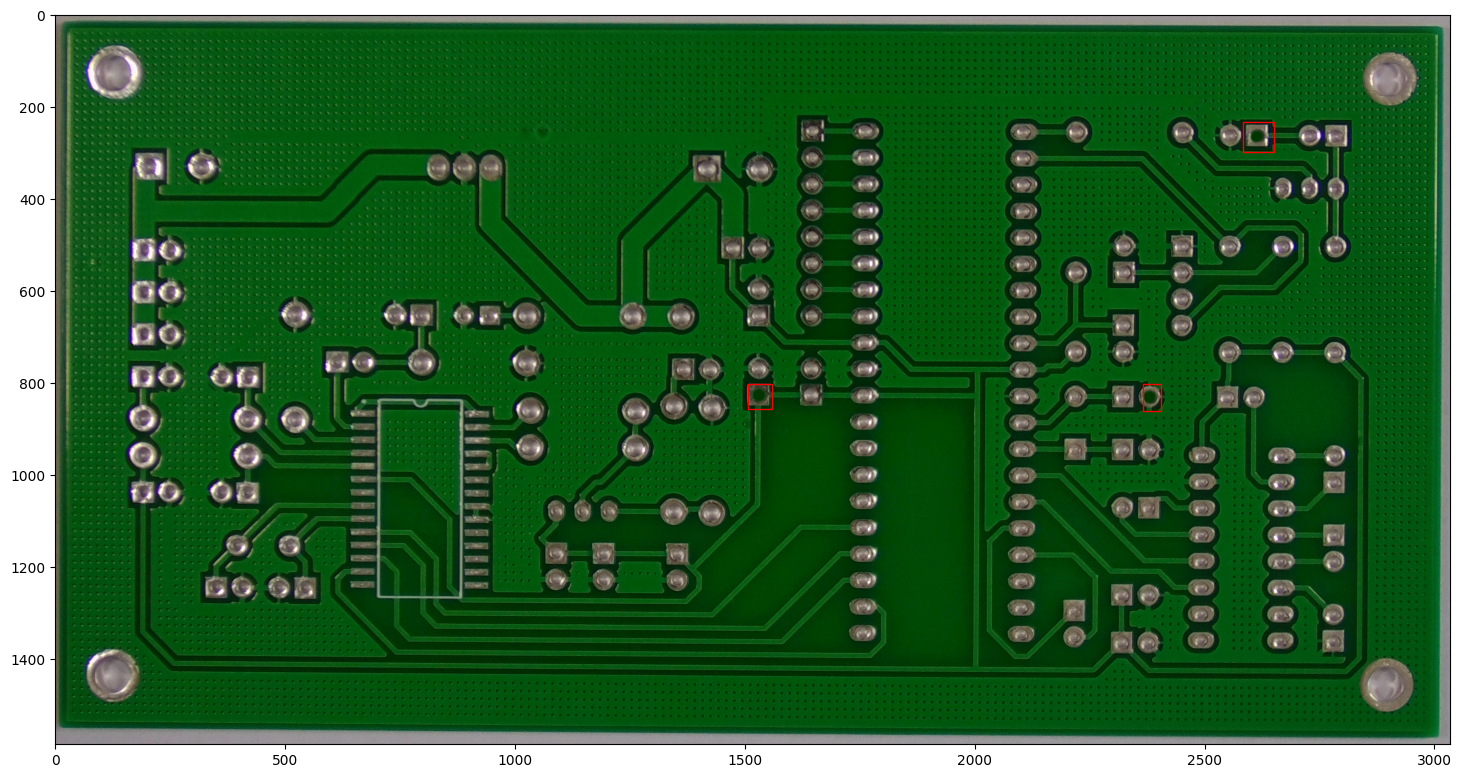

In [21]:
name = '01_missing_hole_02'
plot_image(name)

11_spurious_copper_06
[1314  375 1376  452]
[1634  757 1686  870]
[ 752 1185  863 1237]


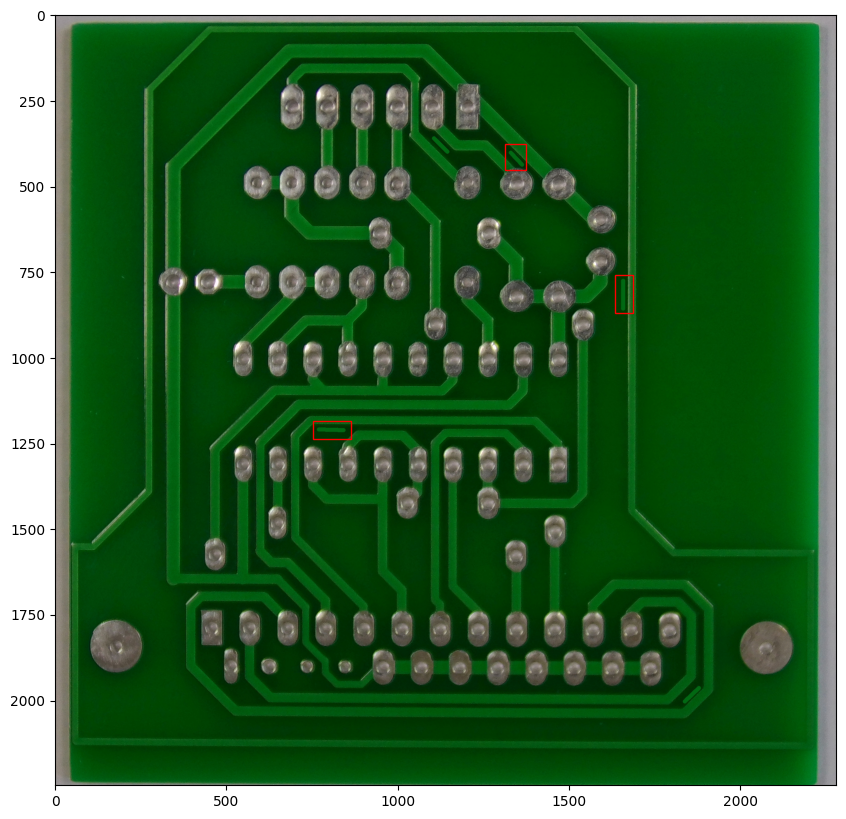

In [22]:
name = train.file[500]
plot_image(name)

05_spurious_copper_06
[1519  653 1649  706]
[1933  363 2056  412]
[1877  782 1980  824]
[1810 1345 1977 1401]


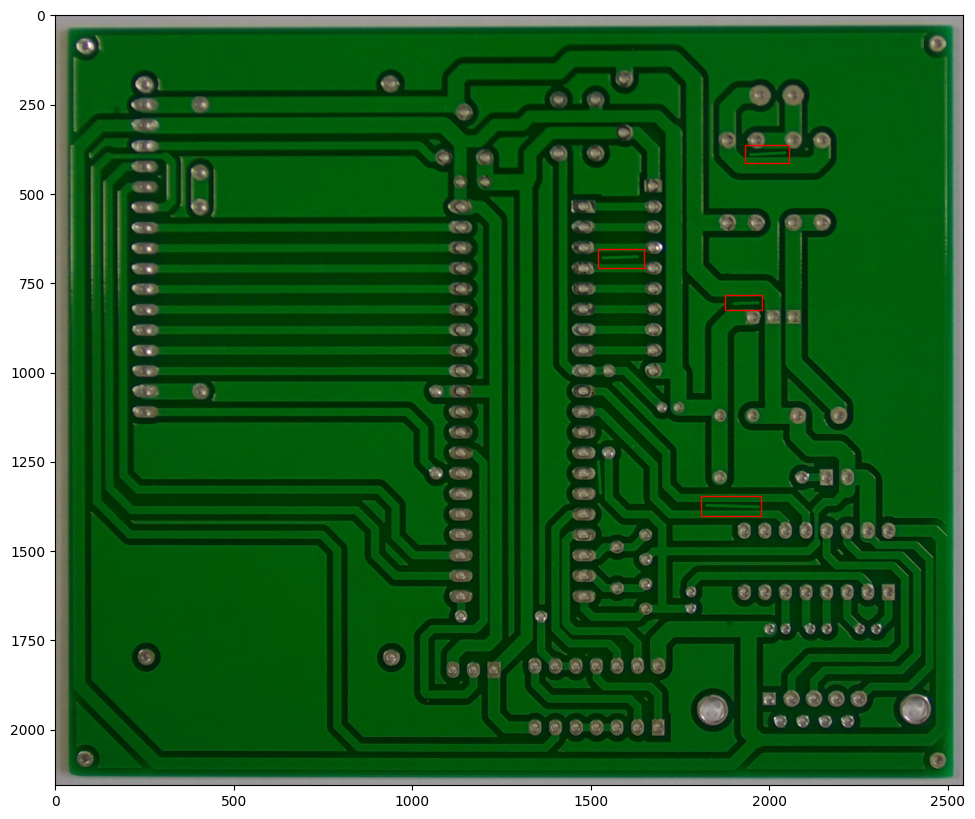

In [23]:
name = train.file[100]
plot_image(name)

08_spurious_copper_10
[2294 1046 2333 1125]
[2069 1052 2110 1129]
[ 863 1225  955 1269]
[1604 1157 1645 1266]
[2410 1275 2487 1320]


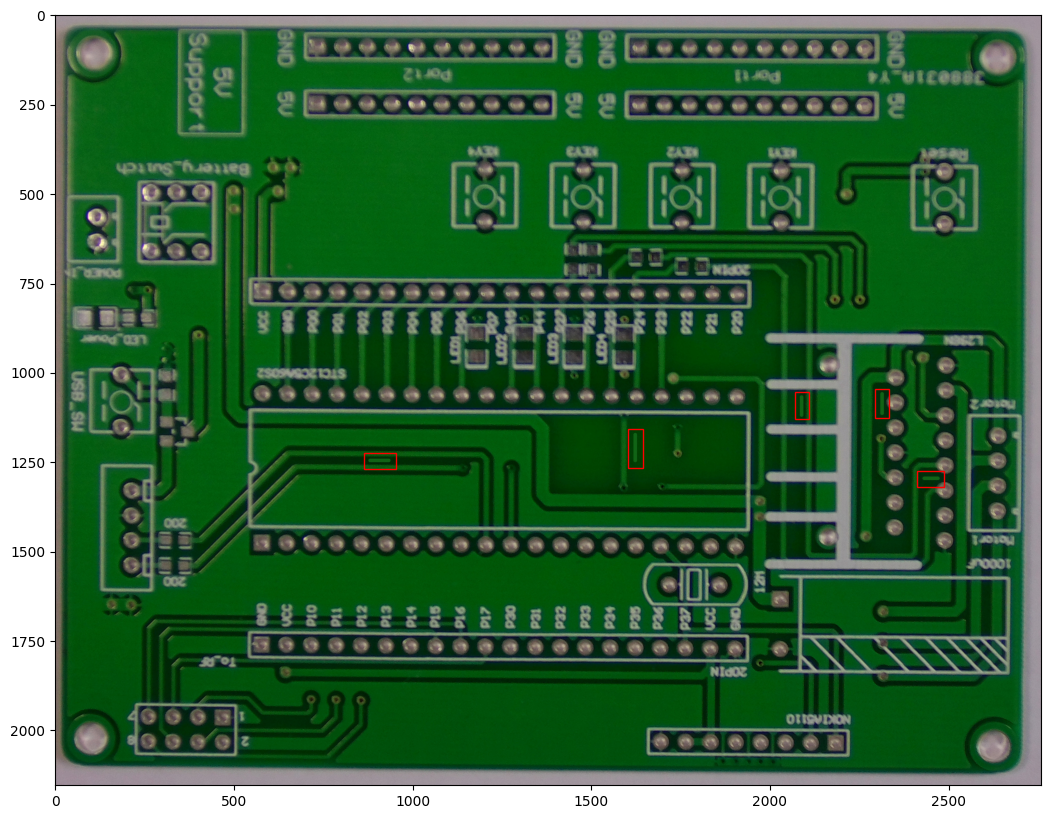

In [24]:
name = train.file[105]
plot_image(name)

In [31]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.preprocessing import LabelEncoder

# Create a global LabelEncoder instance
label_encoder = LabelEncoder()

# Fit the LabelEncoder with all unique labels from your training data
label_encoder.fit(df['class'].unique())  # df is assumed to be your training dataframe

class fcbData(object):
    def __init__(self, df, IMG_DIR, transforms):
        self.df = df
        self.img_dir = IMG_DIR
        self.image_ids = self.df['file'].unique().tolist()
        self.transforms = transforms

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        a = ''
        if "missing" in image_id.split('_'):
            a = 'Missing_hole/'
        elif "mouse" in image_id.split('_'):
            a = 'Mouse_bite/'
        elif "open" in image_id.split('_'):
            a = 'Open_circuit/'
        elif "short" in image_id.split('_'):
            a = 'Short/'
        elif "spur" in image_id.split('_'):
            a = 'Spur/'
        elif "spurious" in image_id.split('_'):
            a = 'Spurious_copper/'
        image_values = self.df[self.df['file'] == image_id]
        image = cv2.imread(self.img_dir+a+image_id+".jpg",cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32)
        image /= 255.0

        boxes = image_values[['xmin', 'ymin', 'xmax', 'ymax']].to_numpy()
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

        labels = image_values["class"].values
        labels = torch.tensor(labels)

        target = {}
        target['boxes'] = boxes
        target['labels'] = labels
        target['image_id'] = torch.tensor([idx])
        target['area'] = torch.as_tensor(area, dtype=torch.float32)
        target['iscrowd'] = torch.zeros(len(classes_la), dtype=torch.int64)

        if self.transforms:
            sample = {
                'image': image,
                'bboxes': target['boxes'],
                'labels': labels
            }
            # Encode labels using the global LabelEncoder
            sample['labels'] = label_encoder.transform(sample['labels'])

            sample = self.transforms(**sample)
            image = sample['image']

            target['boxes'] = torch.stack(tuple(map(torch.tensor, zip(*sample['bboxes'])))).permute(1, 0)

        return torch.tensor(image), target, image_id

In [32]:
def get_train_transform():
    return A.Compose([
        ToTensorV2(p=1.0)
    ], bbox_params={'format': 'pascal_voc', 'label_fields': ['labels']})

def get_valid_transform():
    return A.Compose([
        ToTensorV2(p=1.0)
    ], bbox_params={'format': 'pascal_voc', 'label_fields': ['labels']})

In [33]:
path ="/content/unzipped_files/PCB_DATASET/images/"
fcb_dataset = fcbData(df, path, get_train_transform())
len(df)
path

'/content/unzipped_files/PCB_DATASET/images/'

In [34]:
type(fcb_dataset[0]), len(fcb_dataset[0]), type(fcb_dataset[0][0]), type(fcb_dataset[0][1]), type(fcb_dataset[0][2])

(tuple, 3, torch.Tensor, dict, str)

In [35]:
print([fcb_dataset[0][0], fcb_dataset[0][1], fcb_dataset[0][2]])

[tensor([[[0.6157, 0.6235, 0.6196,  ..., 0.6235, 0.6275, 0.6353],
         [0.6078, 0.6157, 0.6118,  ..., 0.6235, 0.6196, 0.6275],
         [0.6078, 0.6118, 0.6118,  ..., 0.6157, 0.6078, 0.6118],
         ...,
         [0.6000, 0.5922, 0.6039,  ..., 0.6000, 0.5961, 0.5882],
         [0.6078, 0.5922, 0.5961,  ..., 0.6039, 0.6039, 0.6000],
         [0.6118, 0.5961, 0.5961,  ..., 0.6039, 0.6118, 0.6157]],

        [[0.5922, 0.6000, 0.5961,  ..., 0.6000, 0.6039, 0.6118],
         [0.5843, 0.5922, 0.5882,  ..., 0.6000, 0.5961, 0.6039],
         [0.5843, 0.5882, 0.5882,  ..., 0.5922, 0.5843, 0.5882],
         ...,
         [0.5765, 0.5686, 0.5804,  ..., 0.5922, 0.5882, 0.5804],
         [0.5843, 0.5686, 0.5725,  ..., 0.5961, 0.5961, 0.5922],
         [0.5882, 0.5725, 0.5725,  ..., 0.5961, 0.6039, 0.6078]],

        [[0.6078, 0.6157, 0.6118,  ..., 0.6157, 0.6196, 0.6275],
         [0.6000, 0.6078, 0.6039,  ..., 0.6157, 0.6118, 0.6196],
         [0.6000, 0.6039, 0.6039,  ..., 0.6078, 0.6000, 0

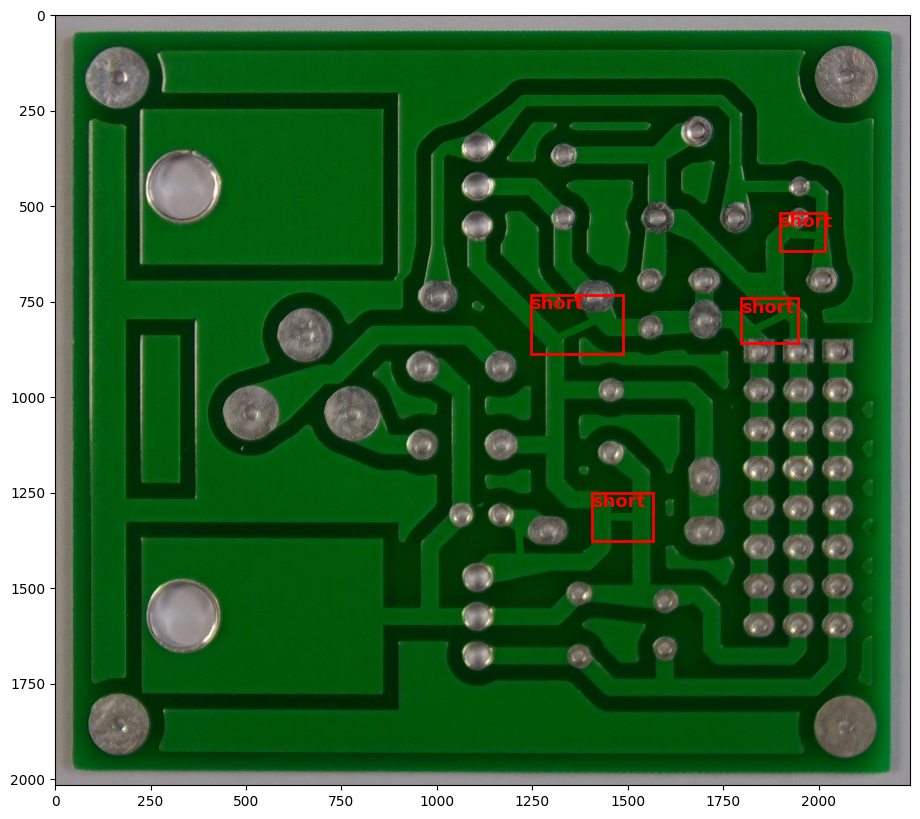

In [36]:
img, tar, _ = fcb_dataset[random.randint(0,50)]
bbox = tar['boxes']
fig,ax = plt.subplots(figsize=(18,10))
ax.imshow(img.permute(1,2,0).cpu().numpy())
for j in tar["labels"].tolist():
    classes_la = {0:"missing_hole", 1: "mouse_bite", 2:"open_circuit",3: "short", 4:'spur',5:'spurious_copper'}
    l = classes_la[j]
    for i in range(len(bbox)):
        box = bbox[i]
        x,y,w,h = box[0], box[1], box[2]-box[0], box[3]-box[1]
        rect = matplotlib.patches.Rectangle((x,y),w,h,linewidth=2,edgecolor='r',facecolor='none',)
        ax.text(*box[:2], l, verticalalignment='top', color='red', fontsize=13, weight='bold')
        ax.add_patch(rect)
    plt.show()

In [37]:
len(df)

2362

In [38]:
image_ids = df['file'].unique()
valid_ids = image_ids[-665:]
train_ids = image_ids[:-665]
valid_df = df[df['file'].isin(valid_ids)]
train_df = df[df['file'].isin(train_ids)]
train_df.shape,valid_df.shape

((106, 8), (2256, 8))

In [39]:
path

'/content/unzipped_files/PCB_DATASET/images/'

In [40]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [41]:
train_dataset = fcbData(df, path, get_train_transform())
valid_dataset = fcbData(df, path, get_valid_transform())

# split the dataset in train and test set
indices = torch.randperm(len(train_dataset)).tolist()

train_data_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=6,
    collate_fn=collate_fn
)

valid_data_loader = DataLoader(
    valid_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=6,
    collate_fn=collate_fn
)

In [42]:
next(iter(train_data_loader))

((tensor([[[0.6157, 0.6235, 0.6196,  ..., 0.6235, 0.6275, 0.6353],
           [0.6078, 0.6157, 0.6118,  ..., 0.6235, 0.6196, 0.6275],
           [0.6078, 0.6118, 0.6118,  ..., 0.6157, 0.6078, 0.6118],
           ...,
           [0.6000, 0.5922, 0.6039,  ..., 0.6000, 0.5961, 0.5882],
           [0.6078, 0.5922, 0.5961,  ..., 0.6039, 0.6039, 0.6000],
           [0.6118, 0.5961, 0.5961,  ..., 0.6039, 0.6118, 0.6157]],
  
          [[0.5922, 0.6000, 0.5961,  ..., 0.6000, 0.6039, 0.6118],
           [0.5843, 0.5922, 0.5882,  ..., 0.6000, 0.5961, 0.6039],
           [0.5843, 0.5882, 0.5882,  ..., 0.5922, 0.5843, 0.5882],
           ...,
           [0.5765, 0.5686, 0.5804,  ..., 0.5922, 0.5882, 0.5804],
           [0.5843, 0.5686, 0.5725,  ..., 0.5961, 0.5961, 0.5922],
           [0.5882, 0.5725, 0.5725,  ..., 0.5961, 0.6039, 0.6078]],
  
          [[0.6078, 0.6157, 0.6118,  ..., 0.6157, 0.6196, 0.6275],
           [0.6000, 0.6078, 0.6039,  ..., 0.6157, 0.6118, 0.6196],
           [0.6000, 0.

In [43]:

num_classes = 6


model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)



in_features = model.roi_heads.box_predictor.cls_score.in_features


model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 153MB/s]


In [44]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [45]:

model.to(device)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params, lr=0.0001, weight_decay=0.0005,)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [ ]:
num_epochs = 10

In [ ]:
train_data_loader

In [ ]:
import sys
best_epoch = 0
min_loss = sys.maxsize

for epoch in range(num_epochs):
    tk = tqdm(train_data_loader)
    model.train();
    for images, targets, image_ids in tk:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values()) #fwd pass
        loss_value = losses.item()

        optimizer.zero_grad()
        losses.backward() # computes the gradients of the loss with respect to each trainable parameter of the model
        optimizer.step()

        tk.set_postfix(train_loss=loss_value)
    tk.close()

    # update the learning rate. The learning rate scheduler modifies the learning rate dynamically during training.
    if lr_scheduler is not None:
        lr_scheduler.step()

    print(f"Epoch #{epoch} loss: {loss_value}")

    #validation
    model.eval();
    with torch.no_grad():
        tk = tqdm(valid_data_loader)
        for images, targets, image_ids in tk:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            val_output = model(images)
            val_output = [{k: v.to(device) for k, v in t.items()} for t in val_output]
            IOU = []
            for j in range(len(val_output)):
                a,b = val_output[j]['boxes'].cpu().detach(), targets[j]['boxes'].cpu().detach()
                chk = torchvision.ops.box_iou(a,b) #Intersection over Union (IoU) Metric:
                res = np.nanmean(chk.sum(axis=1)/(chk>0).sum(axis=1))
                IOU.append(res)
            tk.set_postfix(IoU=np.mean(IOU))
        tk.close()

  0%|          | 0/690 [00:00<?, ?it/s]

Epoch #0 loss: 0.07287172812414572


  0%|          | 0/690 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

Epoch #1 loss: 0.10209990025357832


...

Epoch #8 loss: 0.10546049236899654


  0%|          | 0/690 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

Epoch #9 loss: 0.09234326822363118


  0%|          | 0/690 [00:00<?, ?it/s]

Sample evaluation on validation dataset image

In [ ]:
img,target,_ = valid_dataset[3]
# put the model in evaluation mode
model.eval()
with torch.no_grad():
    prediction = model([img.to(device)])[0]

print('predicted #boxes: ', len(prediction['boxes']))
print('real #boxes: ', len(target['boxes']))

predicted #boxes:  7
real #boxes:  5


In [ ]:
torch.save(model.state_dict(), 'pcbdetection.pt')

In [ ]:
y_true = []
y_pred = []

for i in range(50):
    img, target, _ = valid_dataset[i]
    model.eval()
    with torch.no_grad():
        prediction = model([img.to(device)])[0]

        # Check if there are any predicted labels
        if len(prediction['labels']) > 0:
            y_true.append(target['labels'][0])  # Ground truth label
            y_pred.append(prediction['labels'][0])  # Predicted label
        else:
            # Handle cases where there are no predicted labels
            y_true.append(target['labels'][0])  # Append ground truth label
            y_pred.append(-1)  # Append a default value for no predictions (e.g., -1)


In [ ]:
y_pred

[tensor(3, device='cuda:0'),
 -1,
 tensor(3, device='cuda:0'),
 tensor(2, device='cuda:0'),
 -1,
 -1,
 tensor(2, device='cuda:0'),
 tensor(3, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(1, device='cuda:0'),
 -1,
 tensor(4, device='cuda:0'),
 tensor(2, device='cuda:0'),
 -1,
 tensor(3, device='cuda:0'),
 tensor(4, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(3, device='cuda:0'),
 -1,
 tensor(4, device='cuda:0'),
 tensor(4, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(2, device='cuda:0'),
 tensor(2, device='cuda:0'),
 tensor(2, device='cuda:0'),
 tensor(3, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(3, device='cuda:0'),
 tensor(4, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(2, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(3, device='cuda:0'),
 tensor(3, device='cuda:0'),
 -1,
 -1,
 tensor(4, device='cuda:0'),
 tensor(2, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(2, device='cuda:0'),
 -1

In [ ]:
yy_pred = []
for v in y_pred:
    yy_pred.append(v)  # No need for .cpu() since v is an int


In [ ]:
yy_pred

[tensor(3, device='cuda:0'),
 -1,
 tensor(3, device='cuda:0'),
 tensor(2, device='cuda:0'),
 -1,
 -1,
 tensor(2, device='cuda:0'),
 tensor(3, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(1, device='cuda:0'),
 -1,
 tensor(4, device='cuda:0'),
 tensor(2, device='cuda:0'),
 -1,
 tensor(3, device='cuda:0'),
 tensor(4, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(3, device='cuda:0'),
 -1,
 tensor(4, device='cuda:0'),
 tensor(4, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(2, device='cuda:0'),
 tensor(2, device='cuda:0'),
 tensor(2, device='cuda:0'),
 tensor(3, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(3, device='cuda:0'),
 tensor(4, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(2, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(3, device='cuda:0'),
 tensor(3, device='cuda:0'),
 -1,
 -1,
 tensor(4, device='cuda:0'),
 tensor(2, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(2, device='cuda:0'),
 -1

In [ ]:
y_true

[tensor(3),
 tensor(0),
 tensor(3),
 tensor(2),
 tensor(0),
 tensor(0),
 tensor(2),
 tensor(3),
 tensor(5),
 tensor(1),
 tensor(0),
 tensor(4),
 tensor(2),
 tensor(0),
 tensor(3),
 tensor(4),
 tensor(5),
 tensor(3),
 tensor(0),
 tensor(4),
 tensor(4),
 tensor(5),
 tensor(5),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(0),
 tensor(5),
 tensor(3),
 tensor(4),
 tensor(5),
 tensor(2),
 tensor(5),
 tensor(3),
 tensor(3),
 tensor(0),
 tensor(0),
 tensor(4),
 tensor(2),
 tensor(5),
 tensor(2),
 tensor(0),
 tensor(3),
 tensor(4),
 tensor(0),
 tensor(4),
 tensor(1),
 tensor(5),
 tensor(5),
 tensor(2)]

In [ ]:
import torch
from sklearn.metrics import confusion_matrix

# Move tensors in y_true to CPU and convert to list of integers if necessary
y_true = [int(t.cpu().numpy()) if torch.is_tensor(t) else t for t in y_true]

# Move tensors in yy_pred to CPU and convert to list of integers if necessary
yy_pred = [int(t.cpu().numpy()) if torch.is_tensor(t) else t for t in yy_pred]

# Now calculate confusion matrix
cm = confusion_matrix(y_true, yy_pred)
print(cm)


[[ 9  0  0  0  1  0]
 [ 0  9  0  0  2  0]
 [ 0  0  7  0  2  0]
 [ 0  0  0 10  0  1]
 [ 0  0  1  0  9  0]
 [ 1  0  0  0  0  8]]


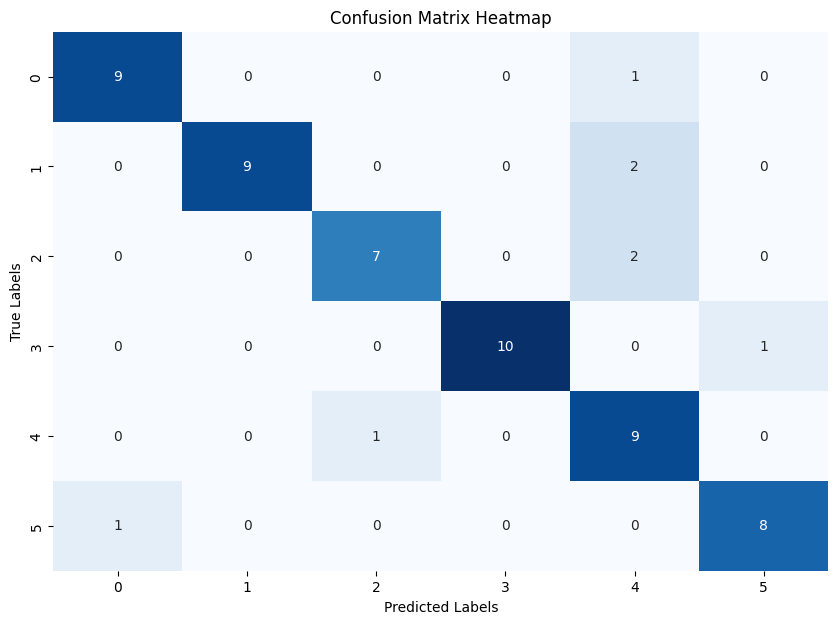

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       1.00      0.82      0.90        11
           2       0.88      0.78      0.82         9
           3       1.00      0.91      0.95        11
           4       0.64      0.90      0.75        10
           5       0.89      0.89      0.89         9

    accuracy                           0.87        60
   macro avg       0.88      0.87      0.87        60
weighted avg       0.89      0.87      0.87        60



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Generate the confusion matrix
cm = confusion_matrix(y_true, yy_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=[str(i) for i in range(len(set(y_true)))],
            yticklabels=[str(i) for i in range(len(set(y_true)))])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Print classification report
print(classification_report(y_true, yy_pred))


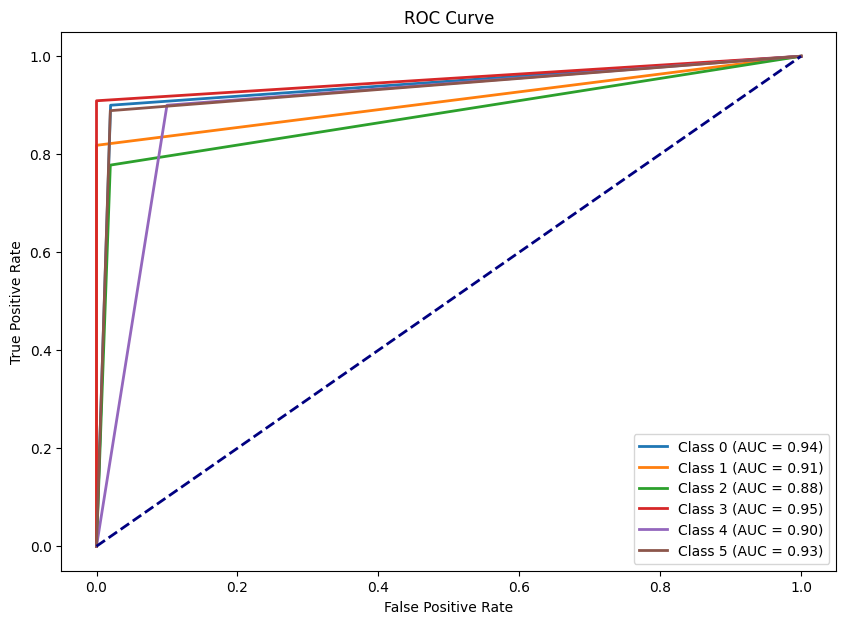

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for ROC curve
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_bin = label_binarize(yy_pred, classes=np.unique(yy_pred))

plt.figure(figsize=(10, 7))
for i in range(y_true_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()


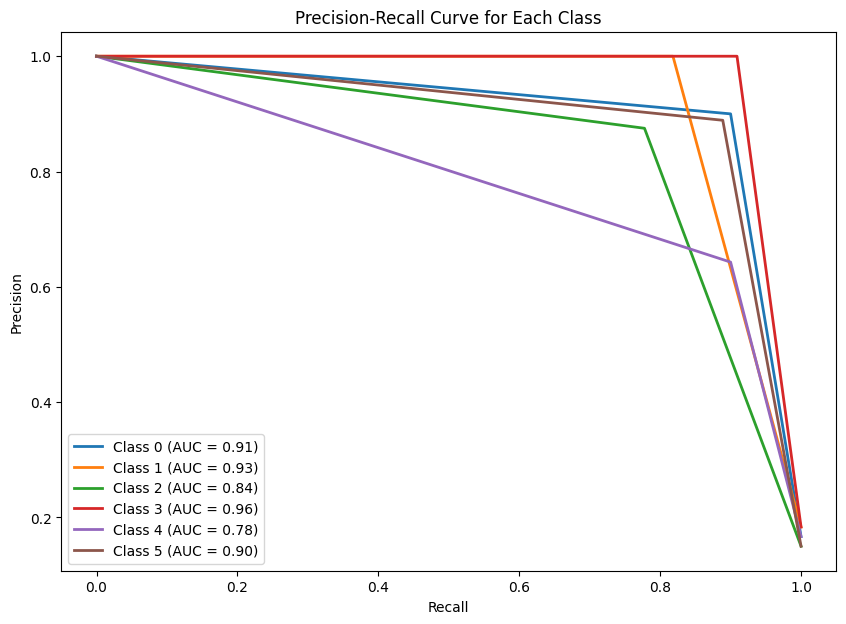

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

# Binarize the true labels and predicted labels
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
yy_pred_bin = label_binarize(yy_pred, classes=np.unique(y_pred))

# Create the plot
plt.figure(figsize=(10, 7))

# Loop over each class to calculate and plot precision-recall curve
for i in range(y_true_bin.shape[1]):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], yy_pred_bin[:, i])

    # Plot the Precision-Recall curve for this class
    plt.plot(recall, precision, lw=2, label=f'Class {i} (AUC = {auc(recall, precision):.2f})')

# Adding labels and title
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Each Class')
plt.legend(loc='best')

# Show the plot
plt.show()
